In [31]:
import requests
import pandas as pd
from datetime import datetime, timezone
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap
from matplotlib.patches import Patch
import matplotlib.dates as mdates
import ast
import folium
from folium.plugins import MarkerCluster
import reverse_geocoder as rg
import re
import pycountry
import os
import numpy as np
import geopandas as gpd
import fiona
import sys
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import ruptures as rpt
from haversine import haversine
import functions as own
from timezonefinder import TimezoneFinder
import zoneinfo
from itertools import product
from scipy.stats import spearmanr
import seaborn as sns
from geopy.distance import geodesic
import wbgapi as wb
from IPython.display import display
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

Distance to Zurich: Mean or Median distance of all observations in a canton to Zurich (47.3717, 8.5422)

In [2]:
df = pd.read_csv("../CWData_Switzerland.csv")

Zurich_coords = (47.3717, 8.5422)

# mean and median coordinates per region
df["distance_to_zurich_km"] = df.apply(
    lambda row: geodesic((row["latitude"], row["longitude"]), Zurich_coords).km, axis=1
)

distance_per_region = (
    df.groupby("Region")
    .agg(
        total_observations=("created_by", "size"),
        distance_to_zurich_km_mean=("distance_to_zurich_km", "mean"),
        distance_to_zurich_km_median=("distance_to_zurich_km", "median"),
    )
    .reset_index()
)

distance_per_region = distance_per_region[distance_per_region["total_observations"] >= 10].reset_index(drop=True)

pd.set_option("display.max_rows", None)
distance_per_region

C:\Users\yanni\AppData\Local\Temp\ipykernel_35808\3658922088.py:1: DtypeWarning: Columns (0: Plastic_PET, 1: Plastic_POSoft, 2: Plastic_POHard, 3: Plastic_PS, 4: Plastic_PSE, 5: Plastic_PMultilayer, 6: Plastic_POther, 7: Plastic_Removed, 8: Plastic_River_Stagnant, 9: Waterlevel_Physical_Unit, 10: Streamtype, 11: Swimming_Quality, 12: Drinking_Quality, 13: Naturality, 14: StreamColor, 15: Stream_Ground_Visibility, 16: Stream_Animals, 17: Stream_Pollution_Reason, 18: Stream_sometimes_dry, 19: Stream_Name, 20: TempStream_snow_ice, 21: Stream_Waterquality, 22: Stream_Waterclarity, 23: StreamColor_other, 24: Stream_Vegetation, 25: Stream_Foam, 26: Stream_Algae, 27: Stream_Odor, 28: Stream_Odor_Type, 29: Stream_Odor_Type_other, 30: Stream_Litter, 31: Stream_Flow_Alteration, 32: Stream_typical_Color, 33: Stream_Drainage_Basin, 34: Lake_Usage, 35: Lake_Usage_Nr, 36: Lake_Access, 37: Lake_Shore_State, 38: Lake_Swimming, 39: Lake_Transparency, 40: Lake_Color, 41: Lake_Odor, 42: Lake_Shore_Vegeta

,Region,total_observations,distance_to_zurich_km_mean,distance_to_zurich_km_median
0,Aargau,1198,22.641442,20.974189
1,Basel-Landschaft,68,61.314949,60.560065
2,Basel-Stadt,23,74.266680,74.744058
3,Bern,2399,91.710775,92.955292
4,Fribourg,69,126.610408,122.264304
5,Genève,44,226.137127,225.401185
6,Glarus,13,54.237324,50.902577
7,Graubünden,310,131.079772,136.929504
8,Lucerne,152,40.515625,38.394168
9,Neuchâtel,15,128.740156,129.983419


Get population, population density, area, GDP per capita for each canton

In [16]:
world_area = gpd.read_file(f"../Borders/swissboundaries3d_2026-01_2056_5728/swissBOUNDARIES3D_1_5_TLM_KANTONSGEBIET.shp", engine="fiona").to_crs("EPSG:2056")
world_area = world_area.rename(columns={"NAME": "Region"})
world_area["area_km2"] = world_area.geometry.area / 1e6

CANTON_NAME_FIXES = {
    "St. Gallen": "Sankt Gallen",
    "Luzern": "Lucerne",
}
world_area["Region"] = world_area["Region"].replace(CANTON_NAME_FIXES)

region_attrs = world_area[["Region", "area_km2"]].copy()

gdp_pop_df = pd.read_csv("../Additional_Data/Switzerland_GDP_Pop.csv", sep=";")
gdp_pop_df = gdp_pop_df[["Region", "GDP per Capita", "Population 1.1.2025 (BFS)"]]

# no education index for Swiss cantons

regression_data = distance_per_region.copy()
regression_data = regression_data.merge(gdp_pop_df, on="Region", how="left")
regression_data = regression_data.merge(region_attrs, on="Region", how="left")

regression_data = regression_data[regression_data["Region"] != "Zürich"]

regression_data = regression_data.rename(columns={"GDP per Capita": "gdp_per_capita", "Population 1.1.2025 (BFS)": "population"})

regression_data

,Region,total_observations,distance_to_zurich_km_mean,distance_to_zurich_km_median,gdp_per_capita,population,area_km2
0,Aargau,1198,22.641442,20.974189,64606.81436,735808,1403.798008
1,Basel-Landschaft,68,61.314949,60.560065,75706.00618,301323,517.668761
2,Basel-Stadt,23,74.266680,74.744058,204601.45340,201384,36.953764
3,Bern,2399,91.710775,92.955292,83421.22820,1071216,5938.892525
4,Fribourg,69,126.610408,122.264304,61797.66608,346674,1672.428050
5,Genève,44,226.137127,225.401185,115291.10070,531102,282.487194
6,Glarus,13,54.237324,50.902577,73577.53062,42371,685.314332
7,Graubünden,310,131.079772,136.929504,81137.53903,206138,7105.296294
8,Lucerne,152,40.515625,38.394168,72895.70014,437944,1493.517213
9,Neuchâtel,15,128.740156,129.983419,104302.70600,179518,802.164263


Random forest regression with population, GDP per capita and median distance to Zurich as dependent, and number of observations as independent variable

Log transformation of number of observations

In [17]:
d = regression_data.dropna(subset=["total_observations", "population", "gdp_per_capita", "distance_to_zurich_km_median", "area_km2"]).copy()

d["log_obs"] = np.log10(d["total_observations"])
d["log_pop"] = np.log10(d["population"])
d["log_gdp"] = np.log10(d["gdp_per_capita"])
d["log_dist"] = np.log10(d["distance_to_zurich_km_median"].clip(lower=1))
d["log_area"] = np.log10(d["area_km2"])

In [19]:
features = ["log_pop", "log_gdp", "log_dist", "log_area"]
X = d[features]
y = d["log_obs"]

# collinearity
display(X.corr().round(2))

,log_pop,log_gdp,log_dist,log_area
log_pop,1.00,0.03,0.27,0.43
log_gdp,0.03,1.00,0.02,-0.60
log_dist,0.27,0.02,1.00,0.30
log_area,0.43,-0.60,0.30,1.00


In [34]:
final_features = ["log_pop", "log_gdp", "log_dist", "log_area"]
final_X = d[final_features]
final_y = d["log_obs"]

rf = RandomForestRegressor(
    n_estimators=1000,
    min_samples_leaf=3,      #against overfitting
    max_features=2,
    random_state=1,
    oob_score=True,
)

loo = LeaveOneOut()
y_true_rf, y_pred_rf = [], []

for train_idx, test_idx in loo.split(final_X):
    X_train, X_test = final_X.iloc[train_idx], final_X.iloc[test_idx]
    y_train, y_test = final_y.iloc[train_idx], final_y.iloc[test_idx]
    
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    
    y_true_rf.append(y_test.values[0])
    y_pred_rf.append(pred[0])

rf_loo_r2 = r2_score(y_true_rf, y_pred_rf)
print(f"RF LOO CV R²: {rf_loo_r2:.3f}")

rf.fit(final_X, final_y)
print(f"OOB R²: {rf.oob_score_:.3f}")

# Permutation Importance instead of impurity-based
perm = permutation_importance(rf, final_X, final_y, n_repeats=50, random_state=1, scoring="r2")
imp = pd.DataFrame({
    "feature": final_features,
    "importance": perm.importances_mean,
    "std": perm.importances_std,
}).sort_values("importance", ascending=False)
print(imp)

RF LOO CV R²: 0.223
OOB R²: 0.212
    feature  importance       std
3  log_area    0.323909  0.097958
0   log_pop    0.312937  0.098113
1   log_gdp    0.078803  0.025414
2  log_dist    0.028029  0.006905


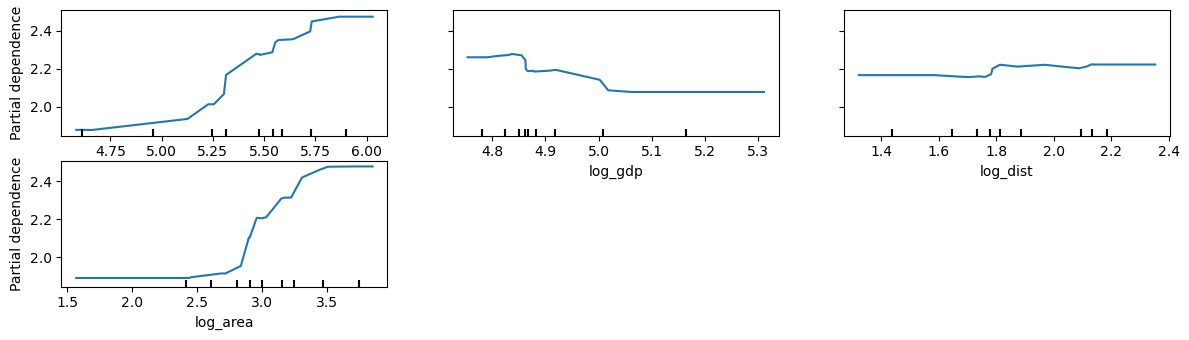

In [21]:
fig, ax = plt.subplots(figsize=(12, 3.5))
PartialDependenceDisplay.from_estimator(rf, final_X, final_features, ax=ax)
plt.tight_layout()
plt.savefig("../Products/Switzerland/Switzerland_RF_partial_dependence.png", dpi=300, bbox_inches="tight")

"Normal" Multiple Regression

In [23]:
X_ols = sm.add_constant(final_X)
ols_model = sm.OLS(final_y, X_ols).fit()

ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                log_obs   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     9.038
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           0.000514
Time:                        13:14:03   Log-Likelihood:                -11.101
No. Observations:                  21   AIC:                             32.20
Df Residuals:                      16   BIC:                             37.42
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1672      5.039     -0.232      0.820     -11.849       9.514
log_pop        0.9836      0.291      3.385      0.004       0.368       1.600
log_gdp       -0.5259      1.008     -0.522      0.609      -2.663       1.611
log_dist      -0.6158      0.410     -1.501      0.153      -1.485       0.254
log_area       0.6030      0.311      1.942      0.070      -0.055       1.261
==============================================================================
Omnibus:                        0.784   Durbin-Watson:                   1.536
Prob(Omnibus):                  0.676   Jarque-Bera (JB):                0.757
Skew:                           0.388   Prob(JB):                        0.685
Kurtosis:                       2.486   Cond. No.                         408.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
loo = LeaveOneOut()
lr = LinearRegression()

y_true, y_pred = [], []

for train_idx, test_idx in loo.split(final_X):
    X_train, X_test = final_X.iloc[train_idx], final_X.iloc[test_idx]
    y_train, y_test = final_y.iloc[train_idx], final_y.iloc[test_idx]
    
    lr.fit(X_train, y_train)
    pred = lr.predict(X_test)
    
    y_true.append(y_test.values[0])
    y_pred.append(pred[0])

loo_r2 = r2_score(y_true, y_pred)
print(f"LOO CV R²: {loo_r2:.3f}")

LOO CV R²: 0.517


In [24]:
X_vif = sm.add_constant(final_X)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data

,feature,VIF
0,const,2410.338515
1,log_pop,1.465732
2,log_gdp,1.972961
3,log_dist,1.188366
4,log_area,2.517273
